In [1]:
# 📥 Load Tenrec Video dataset
import pandas as pd
df = pd.read_csv('../Dataset/QK-video_subset_5M.csv')
df

,user_id,item_id,click,follow,like,share,video_category,watching_times,gender,age
0,1,1,1,0,0,0,1,1,1,4
1,1,2,1,0,0,0,1,1,1,4
2,1,3,1,0,0,0,0,1,1,4
3,1,4,0,0,0,0,1,0,1,4
4,2,5,1,0,0,0,1,1,1,4
...,...,...,...,...,...,...,...,...,...,...
4999995,103552,16309,0,0,0,0,0,1,1,3
4999996,103552,47798,0,0,0,0,0,1,1,3
4999997,103552,3951,1,0,0,0,0,1,1,3
4999998,103552,5880,0,0,0,0,0,1,1,3


In [2]:
# 🔄 Define categorical and numerical features for Tenrec Video dataset
categorical_cols = ['user_id', 'item_id', 'video_category', 'watching_times', 'gender', 'age']
numerical_cols = ['follow', 'like', 'share']
target_col = 'click'

# ✅ Chuyển toàn bộ categorical feature sang số bằng factorize
for col in categorical_cols:
    df[col], _ = pd.factorize(df[col])

# ⛏️ Prepare features and target
X_cat = df[categorical_cols].values
X_num = df[numerical_cols].astype(float).values
y = df[target_col].astype(float).values.reshape(-1, 1)


In [3]:
import torch
import torch.nn as nn

class FMWithNumerical(nn.Module):
    def __init__(self, cat_vocab_sizes, num_numerical, embed_dim=10):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embed_dim) for vocab_size in cat_vocab_sizes
        ])
        self.linear_cat = nn.ModuleList([
            nn.Embedding(vocab_size, 1) for vocab_size in cat_vocab_sizes
        ])
        self.linear_num = nn.Linear(num_numerical, 1)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x_cat, x_num):
        linear_part = sum(self.linear_cat[i](x_cat[:, i]) for i in range(x_cat.shape[1]))
        linear_part = linear_part + self.linear_num(x_num) + self.bias

        embed_list = [self.embeddings[i](x_cat[:, i]) for i in range(x_cat.shape[1])]
        sum_embed = sum(embed_list)
        sum_square = sum_embed ** 2
        square_sum = sum([e ** 2 for e in embed_list])
        interaction = 0.5 * (sum_square - sum(square_sum))

        return linear_part + interaction.sum(1, keepdim=True), embed_list

In [4]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Training on:", device)

BATCH_SIZE = 256
EPOCHS = 1
EMBED_DIM = 10

vocab_sizes = [df[col].max() + 1 for col in categorical_cols]
model = FMWithNumerical(cat_vocab_sizes=vocab_sizes, num_numerical=len(numerical_cols), embed_dim=EMBED_DIM).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

dataset = TensorDataset(
    torch.LongTensor(X_cat),
    torch.FloatTensor(X_num),
    torch.FloatTensor(y)
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

grad_sums = [torch.zeros_like(emb.weight) for emb in model.embeddings]
grad_counts = [torch.zeros_like(emb.weight[:, 0]) for emb in model.embeddings]

for epoch in range(EPOCHS):
    for batch_cat, batch_num, batch_y in loader:
        batch_cat = batch_cat.to(device)
        batch_num = batch_num.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        pred, embed_list = model(batch_cat, batch_num)
        loss = criterion(pred, batch_y)
        loss.backward()

        for i, emb in enumerate(model.embeddings):
            if emb.weight.grad is not None:
                grad_sums[i] += emb.weight.grad.abs()
                grad_counts[i] += (emb.weight.grad != 0).sum(dim=1).float()

        optimizer.step()

# Tính độ lớn gradient trung bình cho từng feature embedding
feature_grads = {}
for i, name in enumerate(categorical_cols):
    mean_grad = (grad_sums[i].sum(dim=1) / grad_counts[i].clamp(min=1)).mean().item()
    feature_grads[name] = mean_grad
    print(f"📊 Mean |∇L/∇v_{name}| = {mean_grad:.6f}")

💻 Training on: cpu
📊 Mean |∇L/∇v_user_id| = 428.051971
📊 Mean |∇L/∇v_item_id| = 528.906006
📊 Mean |∇L/∇v_video_category| = 4546.333984
📊 Mean |∇L/∇v_watching_times| = 598.337708
📊 Mean |∇L/∇v_gender| = 3976.756104
📊 Mean |∇L/∇v_age| = 1505.387329


In [5]:
# Phân tích hệ số và gradient numerical feature
print("\n📊 Numerical Feature Importance (từ linear layer):")
for i, name in enumerate(numerical_cols):
    grad = model.linear_num.weight.grad[0, i].item()
    weight = model.linear_num.weight[0, i].item()
    print(f"🧮 {name}: weight = {weight:.6f}, grad = {grad:.6f}")



📊 Numerical Feature Importance (từ linear layer):
🧮 follow: weight = 9.401743, grad = 10.522336
🧮 like: weight = 14.052104, grad = 21.874012
🧮 share: weight = 12.684034, grad = 11.080766


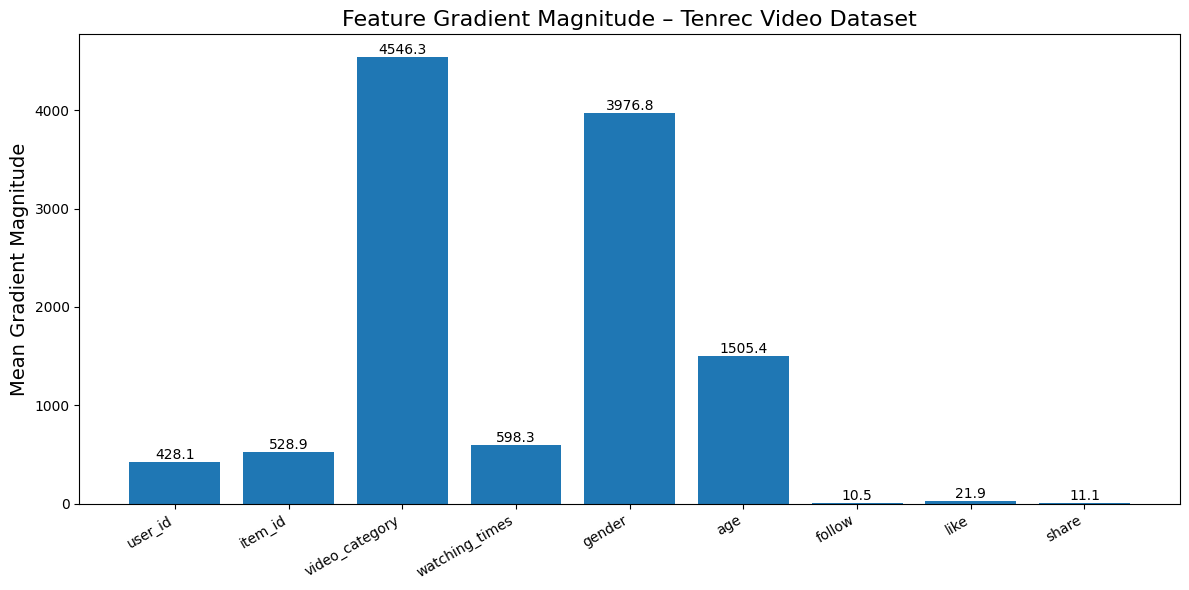

In [6]:
import matplotlib.pyplot as plt

# 🔢 Lấy dữ liệu từ feature_grads (categorical) và model.linear_num.weight.grad (numerical)
cat_names = list(feature_grads.keys())
cat_values = list(feature_grads.values())

num_names = numerical_cols
num_values = [model.linear_num.weight.grad[0, i].item() for i in range(len(numerical_cols))]

# 📈 Tạo figure và vẽ bar chart
plt.figure(figsize=(12, 6))

# Gộp chung categorical + numerical
all_names = cat_names + num_names
all_values = cat_values + num_values

bars = plt.bar(all_names, all_values)

# 🏷️ Thêm giá trị lên trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha='center', va='bottom', fontsize=10)

# 🎨 Trang trí biểu đồ
plt.title("Feature Gradient Magnitude – Tenrec Video Dataset", fontsize=16)
plt.ylabel("Mean Gradient Magnitude", fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
